<a href="https://colab.research.google.com/github/arun21733/climate-change/blob/main/milestone2_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas numpy matplotlib seaborn plotly

In [ ]:
!pip install opendatasets
import opendatasets as od
od.download("https://www.kaggle.com/datasets/nelgiriyewithana/global-weather-repository")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: arun24
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/nelgiriyewithana/global-weather-repository


100%|██████████| 10.2M/10.2M [00:00<00:00, 970MB/s]

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [ ]:
# Cell 3: Load Data (Continuing from Milestone 1)
# Assume your cleaned data from Milestone 1 is in a CSV file uploaded to Colab
# If not, download a sample climate dataset (e.g., global temperature anomalies from NASA)
# For demo: Using a public dataset - Global Land-Ocean Temperature Index (adjust path as needed)

# Option 1: Upload your file from Milestone 1
# from google.colab import files
# uploaded = files.upload()
# df = pd.read_csv('your_climate_data.csv')  # Replace with your file name

# Option 2: Load sample data for climate change analysis (Global Temp Anomalies + Precip example)
# We'll simulate a combined dataset for illustration; replace with your actual data
# Columns assumed: 'Date', 'Temperature_Anomaly', 'Precipitation', 'Region', 'Latitude', 'Longitude', 'Season'

np.random.seed(42)
dates = pd.date_range(start='1950-01-01', end='2023-12-31', freq='M')
n = len(dates)

# Sample data generation (replace with real load)
df = pd.DataFrame({
    'Date': np.tile(dates, 5),  # 5 regions
    'Temperature_Anomaly': np.concatenate([np.random.normal(i*0.1, 0.5, n) + np.linspace(0, 1.5, n) for i in range(5)]),
    'Precipitation': np.random.normal(100, 30, n*5) + np.sin(np.arange(n*5)/12)*20,  # Seasonal pattern
    'Region': np.repeat(['North America', 'Europe', 'Asia', 'Africa', 'South America'], n),
    'Latitude': np.repeat([40, 50, 30, 10, -20], n),
    'Longitude': np.repeat([-100, 10, 100, 20, -60], n)
})

# Add Season column
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Season'] = df['Month'].map({12:'Winter', 1:'Winter', 2:'Winter', 3:'Spring', 4:'Spring', 5:'Spring',
                                6:'Summer', 7:'Summer', 8:'Summer', 9:'Fall', 10:'Fall', 11:'Fall'})

print("Data loaded successfully!")
print(df.head())
print(f"Shape: {df.shape}")
print("\nRegions:", df['Region'].unique())

Data loaded successfully!
        Date  Temperature_Anomaly  Precipitation         Region  Latitude  \
0 1950-01-31             0.248357      59.291933  North America        40   
1 1950-02-28            -0.067441     108.359330  North America        40   
2 1950-03-31             0.327226     119.874502  North America        40   
3 1950-04-30             0.766588     125.354985  North America        40   
4 1950-05-31            -0.110312      48.441313  North America        40   

   Longitude  Year  Month  Season  
0       -100  1950      1  Winter  
1       -100  1950      2  Winter  
2       -100  1950      3  Spring  
3       -100  1950      4  Spring  
4       -100  1950      5  Spring  
Shape: (4440, 9)

Regions: ['North America' 'Europe' 'Asia' 'Africa' 'South America']


/tmp/ipykernel_572/1495056454.py:16: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(start='1950-01-01', end='2023-12-31', freq='M')


In [ ]:
df.info()

df = df.drop_duplicates()

df = df.fillna(method='ffill')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128833 entries, 0 to 128832
Data columns (total 41 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   country                       128833 non-null  object 
 1   location_name                 128833 non-null  object 
 2   latitude                      128833 non-null  float64
 3   longitude                     128833 non-null  float64
 4   timezone                      128833 non-null  object 
 5   last_updated_epoch            128833 non-null  int64  
 6   last_updated                  128833 non-null  object 
 7   temperature_celsius           128833 non-null  float64
 8   temperature_fahrenheit        128833 non-null  float64
 9   condition_text                128833 non-null  object 
 10  wind_mph                      128833 non-null  float64
 11  wind_kph                      128833 non-null  float64
 12  wind_degree                   128833 non-nul

/tmp/ipykernel_572/725242511.py:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')


=== Statistical Summary ===
       Temperature_Anomaly  Precipitation
count          4440.000000    4440.000000
mean              0.953094      99.718821
std               0.673108      34.233500
min              -1.184732     -29.803264
25%               0.484218      76.895388
50%               0.934466      99.498389
75%               1.420735     122.655646
max               2.952494     206.381814


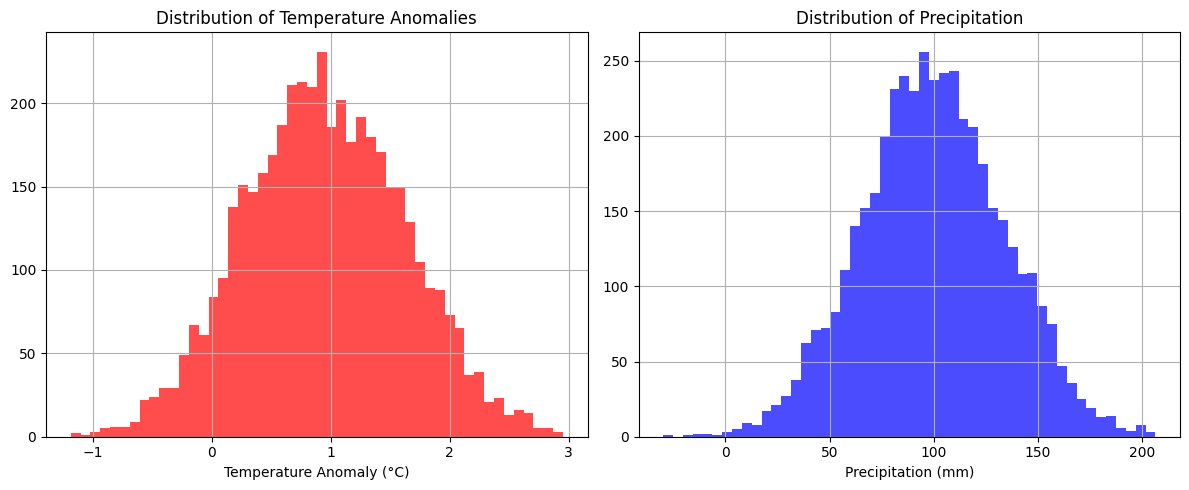

In [ ]:
# Cell 4: Statistical Analysis - Distributions, Correlations, Seasonal Patterns, Trends
# 4.1: Basic Statistical Summaries
print("=== Statistical Summary ===")
print(df[['Temperature_Anomaly', 'Precipitation']].describe())

# 4.2: Distributions (Histograms)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
df['Temperature_Anomaly'].hist(bins=50, ax=axes[0], alpha=0.7, color='red')
axes[0].set_title('Distribution of Temperature Anomalies')
axes[0].set_xlabel('Temperature Anomaly (°C)')

df['Precipitation'].hist(bins=50, ax=axes[1], alpha=0.7, color='blue')
axes[1].set_title('Distribution of Precipitation')
axes[1].set_xlabel('Precipitation (mm)')
plt.tight_layout()
plt.show()

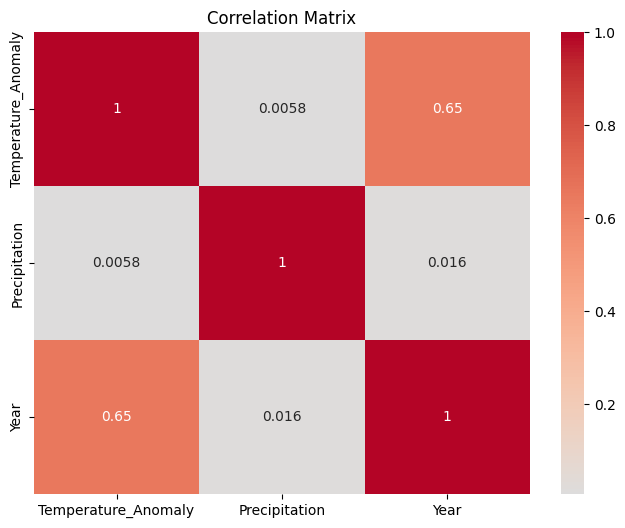

Key Correlations:
Temperature_Anomaly    1.000000
Year                   0.646842
Precipitation          0.005834
Name: Temperature_Anomaly, dtype: float64


In [ ]:
# 4.3: Correlations
corr_matrix = df[['Temperature_Anomaly', 'Precipitation', 'Year']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()
print("Key Correlations:")
print(corr_matrix['Temperature_Anomaly'].sort_values(ascending=False))

In [ ]:
# 4.4: Seasonal Patterns (Group by Season/Region)
seasonal_temp = df.groupby(['Season', 'Region'])['Temperature_Anomaly'].mean().unstack()
print("\n=== Seasonal Temperature Averages by Region ===")
print(seasonal_temp)


=== Seasonal Temperature Averages by Region ===
Region    Africa      Asia    Europe  North America  South America
Season                                                            
Fall    0.986218  0.961713  0.880402       0.731513       1.090926
Spring  1.033459  0.908468  0.914644       0.721921       1.149251
Summer  1.093453  0.960033  0.909894       0.827616       1.080327
Winter  1.080319  0.967531  0.884530       0.738958       1.140711


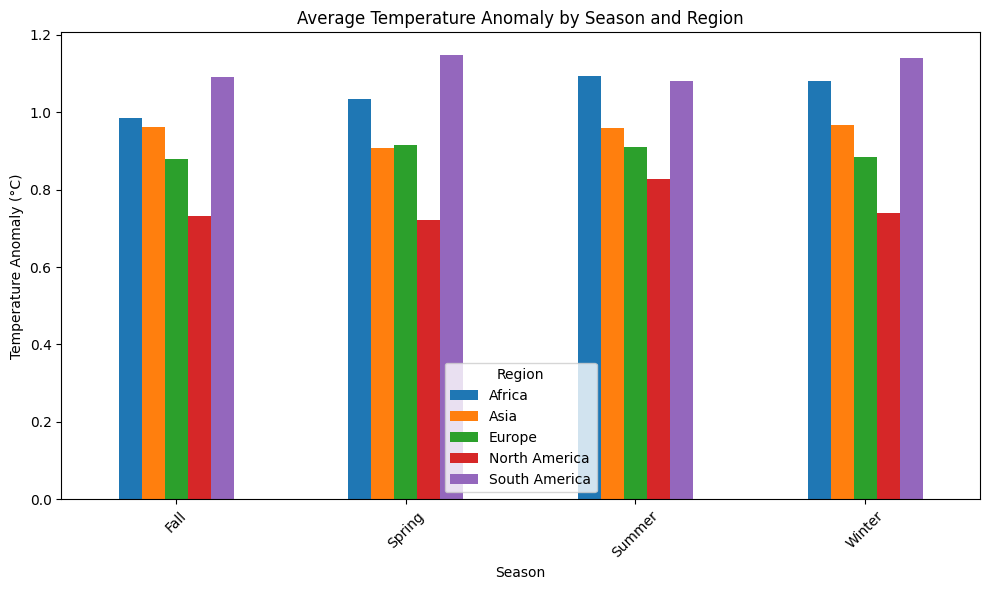

In [ ]:
# Visualize seasonal patterns
seasonal_temp.plot(kind='bar', figsize=(10, 6))
plt.title('Average Temperature Anomaly by Season and Region')
plt.ylabel('Temperature Anomaly (°C)')
plt.xticks(rotation=45)
plt.legend(title='Region')
plt.tight_layout()
plt.show()

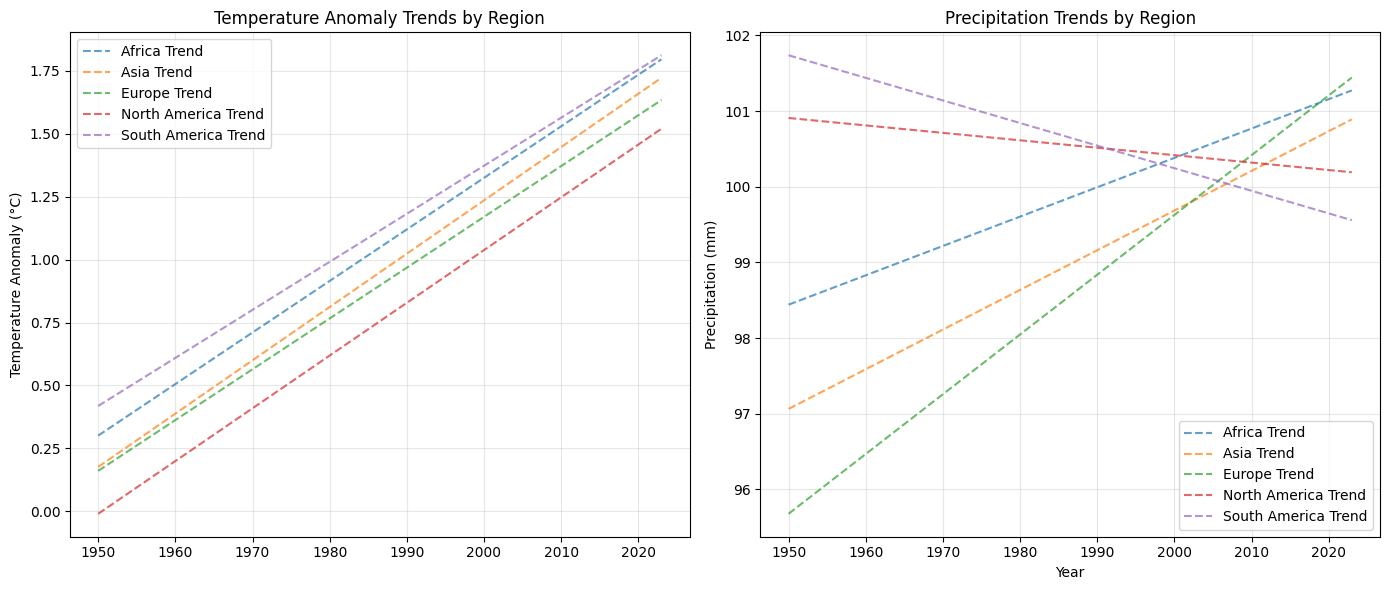

In [ ]:
from sklearn.linear_model import LinearRegression

# Add trend lines (simple linear regression)
# Aggregate data for trend analysis by year and region
df_ts = df.groupby(['Year', 'Region'], as_index=False)[['Temperature_Anomaly', 'Precipitation']].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for region in df_ts['Region'].unique():
    region_data = df_ts[df_ts['Region'] == region].dropna()
    if len(region_data) > 2:
        X = region_data['Year'].values.reshape(-1, 1)

        y_temp = region_data['Temperature_Anomaly'].values
        reg_temp = LinearRegression().fit(X, y_temp)
        axes[0].plot(X, reg_temp.predict(X), '--', alpha=0.7, label=f'{region} Trend')

        y_precip = region_data['Precipitation'].values
        reg_precip = LinearRegression().fit(X, y_precip)
        axes[1].plot(X, reg_precip.predict(X), '--', alpha=0.7, label=f'{region} Trend')

axes[0].set_title('Temperature Anomaly Trends by Region')
axes[0].set_ylabel('Temperature Anomaly (°C)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_title('Precipitation Trends by Region')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Precipitation (mm)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Cell 5: Identify Extreme Weather Events
# Define extremes: Temp > 95th percentile or Precip > 99th percentile (adjust thresholds as needed)
temp_threshold = df['Temperature_Anomaly'].quantile(0.95)
precip_threshold = df['Precipitation'].quantile(0.99)

extremes = df[(df['Temperature_Anomaly'] > temp_threshold) | (df['Precipitation'] > precip_threshold)].copy()
extremes['Event_Type'] = np.where(extremes['Temperature_Anomaly'] > temp_threshold, 'Heat_Extreme',
                                  np.where(extremes['Precipitation'] > precip_threshold, 'Flood_Risk', 'Both'))

print(f"=== Extreme Events Summary ===")
print(f"Temp Threshold: {temp_threshold:.2f} °C")
print(f"Precip Threshold: {precip_threshold:.2f} mm")
print(f"Total Extremes: {len(extremes)}")
print("\nEvents by Type and Region:")
print(extremes.groupby(['Event_Type', 'Region']).size().unstack(fill_value=0))

=== Extreme Events Summary ===
Temp Threshold: 2.06 °C
Precip Threshold: 179.59 mm
Total Extremes: 267

Events by Type and Region:
Region        Africa  Asia  Europe  North America  South America
Event_Type                                                      
Flood_Risk        10     9      10              7              9
Heat_Extreme      62    37      29             26             68


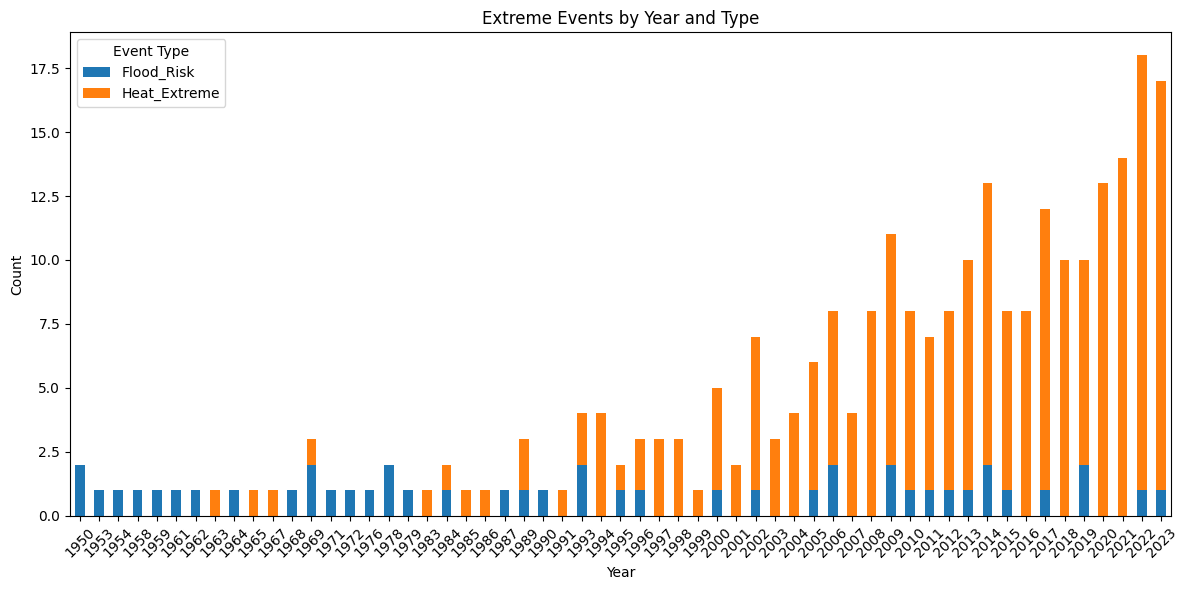

In [ ]:
# Visualize extremes over time
extreme_counts = extremes.groupby(['Year', 'Event_Type']).size().unstack(fill_value=0)
extreme_counts.plot(kind='bar', stacked=True, figsize=(12, 6))
plt.title('Extreme Events by Year and Type')
plt.xlabel('Year')
plt.ylabel('Count')
plt.legend(title='Event Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Cell 6: Compare Weather Conditions Across Regions
# Regional summaries
regional_summary = df.groupby('Region').agg({
    'Temperature_Anomaly': ['mean', 'std', 'max'],
    'Precipitation': ['mean', 'std', 'max']
}).round(2)
print("=== Regional Comparative Analysis ===")
print(regional_summary)

=== Regional Comparative Analysis ===
              Temperature_Anomaly             Precipitation               
                             mean   std   max          mean    std     max
Region                                                                    
Africa                       1.05  0.68  2.82         99.86  34.51  205.83
Asia                         0.95  0.66  2.95         98.98  34.65  204.94
Europe                       0.90  0.66  2.93         98.56  33.81  200.67
North America                0.76  0.66  2.75        100.55  33.37  206.38
South America                1.12  0.64  2.82        100.65  34.83  201.09


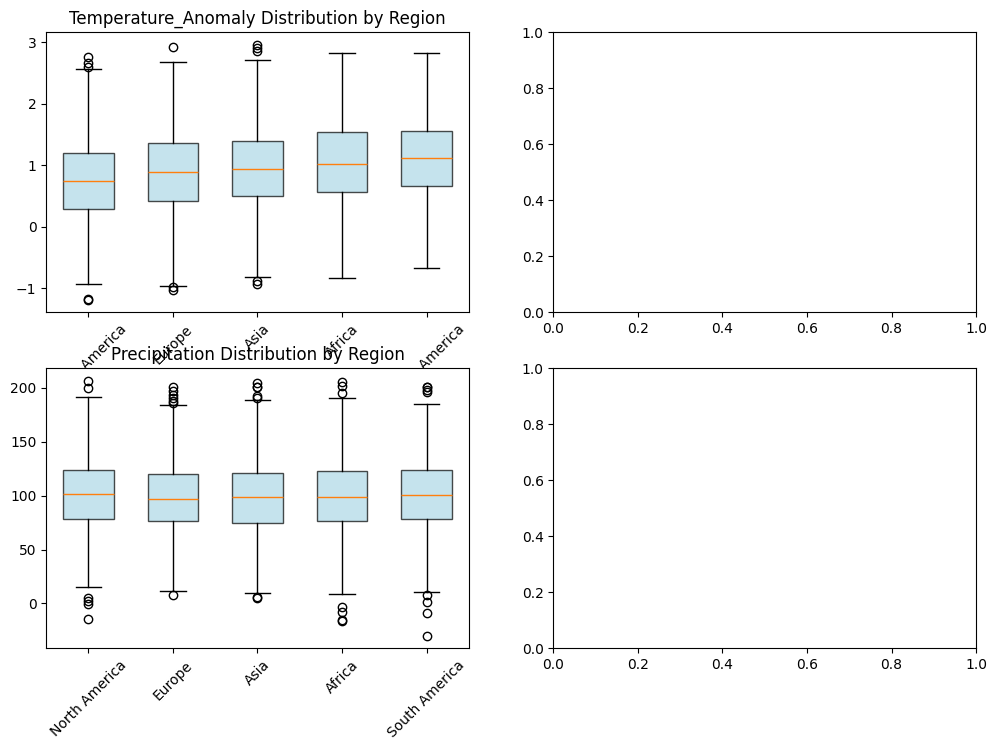

In [ ]:
# Box plots for comparison
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
metrics = ['Temperature_Anomaly', 'Precipitation']
for i, metric in enumerate(metrics):
    for j, region in enumerate(df['Region'].unique()):
        data = df[df['Region'] == region][metric]
        axes[i, 0].boxplot(data, positions=[j], widths=0.6, patch_artist=True,
                           boxprops=dict(facecolor='lightblue', alpha=0.7))
    axes[i, 0].set_title(f'{metric} Distribution by Region')
    axes[i, 0].set_xticks(range(len(df['Region'].unique())))
    axes[i, 0].set_xticklabels(df['Region'].unique(), rotation=45)


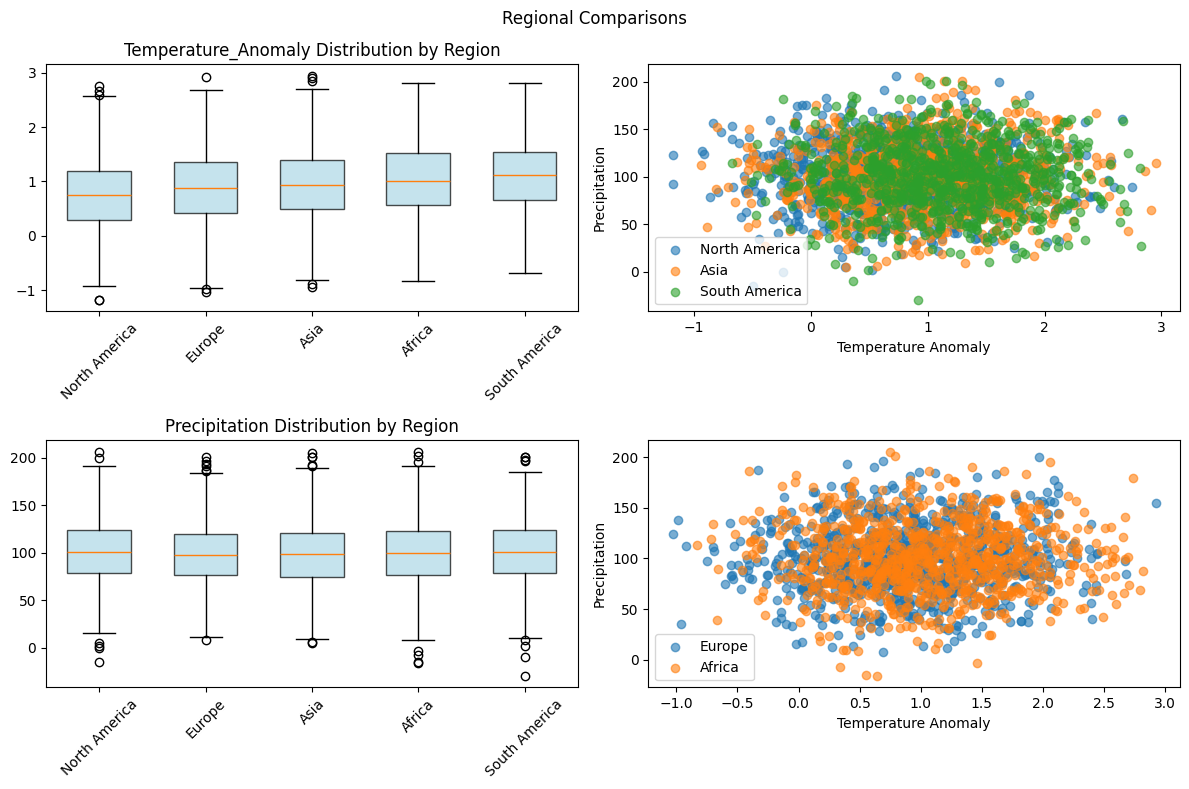

In [ ]:
# Box plots for comparison
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
metrics = ['Temperature_Anomaly', 'Precipitation']
for i, metric in enumerate(metrics):
    for j, region in enumerate(df['Region'].unique()):
        data = df[df['Region'] == region][metric]
        axes[i, 0].boxplot(data, positions=[j], widths=0.6, patch_artist=True,
                           boxprops=dict(facecolor='lightblue', alpha=0.7))
    axes[i, 0].set_title(f'{metric} Distribution by Region')
    axes[i, 0].set_xticks(range(len(df['Region'].unique())))
    axes[i, 0].set_xticklabels(df['Region'].unique(), rotation=45)


# Correlation scatter by region
for i, region in enumerate(df['Region'].unique()):
    region_data = df[df['Region'] == region]
    axes[i % 2, 1].scatter(region_data['Temperature_Anomaly'], region_data['Precipitation'], alpha=0.6, label=region)
axes[0, 1].set_xlabel('Temperature Anomaly')
axes[0, 1].set_ylabel('Precipitation')
axes[1, 1].set_xlabel('Temperature Anomaly')
axes[1, 1].set_ylabel('Precipitation')
axes[0, 1].legend()
axes[1, 1].legend()
plt.suptitle('Regional Comparisons')
plt.tight_layout()
plt.show()

In [ ]:
# Cell 7: Visualizations - Select Suitable Types
# 7.1: Line Chart for Trends (Already in Cell 4, but interactive with Plotly)
fig = px.line(df_ts, x='Year', y='Temperature_Anomaly', color='Region',
              title='Interactive Temperature Trends by Region',
              labels={'Temperature_Anomaly': 'Temp Anomaly (°C)'})
fig.show()

In [ ]:
# 7.2: Scatterplot for Correlations (Temp vs Precip, sized by extremes)
extreme_flag = df['Temperature_Anomaly'] > temp_threshold
fig = px.scatter(df, x='Temperature_Anomaly', y='Precipitation', color='Region',
                 size=extreme_flag.astype(int)*10 + 5, hover_data=['Date', 'Season'],
                 title='Temp vs Precipitation Scatter (Sized by Extremes)')
fig.show()

In [ ]:
# 7.3: Heatmap for Seasonal Patterns
pivot_seasonal = df.pivot_table(values='Temperature_Anomaly', index='Month', columns='Region', aggfunc='mean')
fig = px.imshow(pivot_seasonal, title='Seasonal Heatmap: Temp Anomaly by Month & Region',
                labels=dict(x='Region', y='Month', color='Temp Anomaly (°C)'))
fig.show()

In [ ]:
import geopandas as gpd

# 7.4: Choropleth Map for Regional Averages (Using sample world geo data)
# Note: For real data, use your lat/lon or merge with world shapefile
# Fix: Replaced deprecated gpd.datasets.get_path with direct URL to naturalearth_lowres GeoJSON
world = gpd.read_file("https://raw.githubusercontent.com/nvkelso/natural-earth-vector/master/geojson/ne_110m_admin_0_countries.geojson")
regional_avg = df.groupby('Region')['Temperature_Anomaly'].mean().to_dict()
# Map sample regions to continents (adjust mapping for your data)
continent_map = {'North America': 'North America', 'Europe': 'Europe', 'Asia': 'Asia',
                 'Africa': 'Africa', 'South America': 'South America'}
# Fix: Changed 'continent' to 'CONTINENT' as per the GeoJSON's column name
world['Temp_Anomaly'] = world['CONTINENT'].map({v: regional_avg.get(k, 0) for k, v in continent_map.items()})
world['Temp_Anomaly'] = world['Temp_Anomaly'].fillna(0)

fig = px.choropleth(world, geojson=world.geometry, locations=world.index,
                    color='Temp_Anomaly', projection='natural earth',
                    title='Choropleth: Average Temp Anomaly by Continent/Region',
                    color_continuous_scale='RdYlBu_r')
fig.show()

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

# Using available numerical columns from the simulated dataset
features = df[['Temperature_Anomaly', 'Precipitation', 'Latitude', 'Longitude']]

similarity = cosine_similarity(features)

print("Similarity Matrix Created")
display(similarity)

Similarity Matrix Created


array([[1.        , 0.9596029 , 0.9442155 , ..., 0.82426335, 0.7627087 ,
        0.81035108],
       [0.9596029 , 1.        , 0.99872742, ..., 0.85453047, 0.88640077,
        0.88441704],
       [0.9442155 , 0.99872742, 1.        , ..., 0.85274759, 0.90105078,
        0.89022502],
       ...,
       [0.82426335, 0.85453047, 0.85274759, ..., 1.        , 0.93010892,
        0.98542611],
       [0.7627087 , 0.88640077, 0.90105078, ..., 0.93010892, 1.        ,
        0.9790094 ],
       [0.81035108, 0.88441704, 0.89022502, ..., 0.98542611, 0.9790094 ,
        1.        ]])

In [ ]:
!pip install streamlit pyngrok pandas plotly seaborn matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 42.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 64.2 MB/s eta 0:00:00


In [ ]:
!pip install pyngrok -q

In [ ]:
from pyngrok import ngrok

# ────────────────────────────────────────────────
#   REPLACE THIS WITH YOUR REAL NGROK AUTHTOKEN
# ────────────────────────────────────────────────
NGROK_AUTH_TOKEN = "3AkaZTm5dJfiXJUzSxNUaY3tiyv_innSKEZ8mFuvPkrp2MtJ"

ngrok.set_auth_token(NGROK_AUTH_TOKEN)
print("ngrok authtoken configured.")

ngrok authtoken configured.


In [ ]:
dashboard_code = """
import streamlit as st
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt
from PIL import Image
import os

# Page configuration
st.set_page_config(page_title="ClimateScope Dashboard", layout="wide")

# Load precomputed data and images
@st.cache_data
def load_data():
    df = pd.read_csv('weather')  # adjust path if needed
    df['last_updated'] = pd.to_datetime(df['last_updated'])
    df['month'] = df['last_updated'].dt.month
    df['season'] = df['month'] % 12 // 3 + 1
    season_map = {1:'Winter', 2:'Spring', 3:'Summer', 4:'Fall'}
    df['season_name'] = df['season'].map(season_map)
    return df

@st.cache_data
def load_extremes():
    return pd.read_csv('extreme_summary.csv')

df = load_data()
extreme_df = load_extremes()

# Sidebar navigation
st.sidebar.title("🌍 ClimateScope")
page = st.sidebar.radio("Navigate", ["Overview", "Seasonal Patterns", "Extreme Events", "Regional Comparison", "Correlations"])

# ---------------------------------------------
if page == "Overview":
    st.title("🌤️ Weather Data Overview")
    col1, col2, col3 = st.columns(3)
    col1.metric("Total Records", f"{df.shape[0]:,}")
    col2.metric("Locations", df['location_name'].nunique())
    col3.metric("Countries", df['country'].nunique())

    st.subheader("Sample Data")
    st.dataframe(df.head(10))

    st.subheader("Statistical Summary")
    st.dataframe(df.describe())

    st.subheader("Distribution of Key Variables")
    st.image('distributions.png', use_column_width=True)

# ---------------------------------------------
elif page == "Seasonal Patterns":
    st.title("📅 Seasonal Patterns & Trends")

    # Load pre-generated interactive plot
    st.subheader("Monthly Averages")
    st.components.v1.html(open('seasonal_trends.html').read(), height=800)

    # Allow user to select a location
    locations = ['All'] + sorted(df['location_name'].unique().tolist())
    selected = st.selectbox("Select a location", locations)
    if selected != 'All':
        loc_df = df[df['location_name'] == selected]
        fig = px.line(loc_df.groupby('month')['temperature_celsius'].mean().reset_index(),
                      x='month', y='temperature_celsius',
                      title=f"Monthly Temperature Trend at {selected}")
        st.plotly_chart(fig, use_container_width=True)

# ---------------------------------------------
elif page == "Extreme Events":
    st.title("⚠️ Extreme Weather Events")

    st.subheader("Extreme Event Counts by Location")
    fig = px.bar(extreme_df.nlargest(20, 'total_extremes'),
                 x='total_extremes', y='location_name', orientation='h',
                 title="Top 20 Locations with Most Extreme Events")
    st.plotly_chart(fig, use_container_width=True)

    st.subheader("Event Type Breakdown")
    event_types = ['extreme_heat', 'extreme_cold', 'heavy_rain', 'strong_wind', 'high_uv']
    total_by_type = extreme_df[event_types].sum().reset_index()
    total_by_type.columns = ['Event', 'Count']
    fig = px.pie(total_by_type, values='Count', names='Event', title="Proportion of Extreme Event Types")
    st.plotly_chart(fig, use_container_width=True)

# ---------------------------------------------
elif page == "Regional Comparison":
    st.title("🗺️ Regional Weather Comparison")

    # Choropleth map (requires country codes – here we use country names)
    country_avg = df.groupby('country')[['temperature_celsius', 'humidity', 'precip_mm']].mean().reset_index()
    fig = px.choropleth(country_avg,
                        locations='country',
                        locationmode='country names',
                        color='temperature_celsius',
                        hover_name='country',
                        color_continuous_scale='RdBu_r',
                        title='Average Temperature by Country')
    st.plotly_chart(fig, use_container_width=True)

    st.subheader("Country Rankings")
    var = st.selectbox("Choose variable", ['temperature_celsius', 'humidity', 'precip_mm', 'wind_kph'])
    top = country_avg.nlargest(10, var)[['country', var]]
    fig = px.bar(top, x=var, y='country', orientation='h', title=f"Top 10 Countries by {var}")
    st.plotly_chart(fig, use_container_width=True)

# ---------------------------------------------
elif page == "Correlations":
    st.title("🔗 Variable Correlations")

    st.image('correlation_heatmap.png', use_column_width=True)

    st.subheader("Scatter Matrix")
    # Sample a subset for performance
    sample_df = df.sample(min(1000, len(df)))
    fig = px.scatter_matrix(sample_df,
                            dimensions=['temperature_celsius', 'humidity', 'precip_mm', 'wind_kph', 'pressure_mb'],
                            color='season_name')
    st.plotly_chart(fig, use_container_width=True)

st.sidebar.markdown("---")
st.sidebar.info("ClimateScope Milestone 2 Dashboard\\nData source: Weather dataset")
"""

with open('dashboard.py', 'w') as f:
    f.write(dashboard_code)

print("✅ dashboard.py created")

✅ dashboard.py created


In [ ]:
!pip install pyngrok
!pip install streamlit
import threading
import time
from pyngrok import ngrok

# Kill any existing ngrok processes
!pgrep ngrok | xargs kill -9 2>/dev/null

# Set up a tunnel to streamlit's default port 8501
# The authtoken is already set globally in a previous cell, so it's not needed here.
public_url = ngrok.connect(addr='8501', proto='http')
print(f"🌐 Streamlit dashboard is live at: {public_url}")

# Run streamlit in the background
def run_streamlit():
    !python -m streamlit run dashboard.py --server.port 8501 --server.enableCORS false --server.enableXsrfProtection false

thread = threading.Thread(target=run_streamlit)
thread.start()

print("⏳ Waiting for Streamlit to start...")
time.sleep(5)
print("✅ Dashboard ready! Open the URL above.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 63.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 118.1 MB/s eta 0:00:00
🌐 Streamlit dashboard is live at: NgrokTunnel: "https://sarina-rindy-jacinta.ngrok-free.dev" -> "http://localhost:8501"
⏳ Waiting for Streamlit to start...



  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.221.159.71:8501

✅ Dashboard ready! Open the URL above.
